# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** 24_25_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra   
**Last Updated:** 2026-02-27
### Cost and ILP optimization workflow
**Goal:** Generate a cost matrix for the geometry using the timber datasets, then use ILP to find the best matches.
**Inputs:**
*   CSV timber dataset
*   Digital geometry

**Outputs:**
*   Best match for each structural element

# IMPORTING

## Dataset

In [1]:
import config
import pandas as pd

testing = False
if testing:
    file_path = config.TIMBER_STOCK_PATH / 'complete_timber_small.csv'
else:
    file_path = config.TIMBER_STOCK_PATH / 'complete_timber.csv'

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Detected columns:", df_input_stock.columns.tolist())
print(f"\nDataset contains {df_input_stock.shape[0]} elements\n")
display(df_input_stock.head())

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

Loaded with sep=';' and encoding='utf-8'
Detected columns: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'ECC', 'Origin_Country', 'Transport_Dist', 'EmissionFactor', 'ProcessingFactor']

Dataset contains 324 elements



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,ECC,Origin_Country,Transport_Dist,EmissionFactor,ProcessingFactor
0,NS_00000,0,1500.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Finland,1688.82,0.1743,0
1,NS_00001,0,1500.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Germany,341.61,0.1724,0
2,NS_00002,0,1500.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Poland,816.74,0.1778,0
3,NS_00003,0,1500.0,100.0,75.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Finland,1707.28,0.1771,0
4,NS_00004,0,1500.0,100.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Belgium,145.43,0.1777,0


## Search space

The search space is imported from the geometry script. Then a random design is selected as the starting point for optimization.

In [2]:
import json
import config

json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded. The optimizer can control {len(optimizer_search_space)} parameters.")


Search space loaded. The optimizer can control 18 parameters.


This script is intended for a Colab environment. It reads search_space.json, sets parameters dynamically based on your rules, and uses a placeholder prediction (to be replaced later by the actual neural network) to find the best design.

# GEOMETRY

## Random geometry

In [3]:
import json
import random
import c11_params
from geometry import generate_sample_vertices
from reconstruction import reconstruct_edges

# ==========================================
# 1. GENERATE RANDOM PARAMETERS (the design "DNA")
# ==========================================
def get_random_design(json_path):
    """Read the search space and sample one random value for each variable."""
    with open(json_path, 'r') as f:
        search_space = json.load(f)

    random_params = {}

    for var_name, rules in search_space.items():
        if rules['type'] == 'continuous':
            # Choose a random float value (for example u and v)
            random_params[var_name] = random.uniform(rules['min'], rules['max'])

        elif rules['type'] == 'discrete':
            # Choose exactly one allowed step option (for example shift_x)
            random_params[var_name] = random.choice(rules['options'])

    return random_params

# --- TEST THE FUNCTION ---
print("Step 1: Generating random design DNA...")
my_random_design = get_random_design(json_path)

print("\nSuccess. This is the DNA for the sample design:")
for key, value in my_random_design.items():
    print(f" - {key}: \t{value:.3f}")

# ==========================================
# 2. TRANSLATE DNA TO 3D GEOMETRY (Vertices + Edges)
# ==========================================
print("Step 2: Translating DNA to 3D geometry...")

# Use the design generated in the previous lines
vertices_list = generate_sample_vertices(sample_id=0, params=my_random_design)
df_vertices = pd.DataFrame(vertices_list)
df_edges = reconstruct_edges(c11_params.GRID_CELLS_X, c11_params.GRID_CELLS_Y)

print(f"Success. Geometry built with {len(df_vertices)} nodes and {len(df_edges)} members.")
print("\nExample of generated vertices (first 5):")
print(df_vertices.head())

parameters loaded from c:\Users\jaspe\Documents\PyRepo\thesis_generative_timber\c11_params.py
GRID: 2x2, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

Step 1: Generating random design DNA...

Success. This is the DNA for the sample design:
 - v1_shift_x: 	-0.375
 - v3_shift_y: 	-0.375
 - v4_shift_x: 	1.125
 - v4_shift_y: 	0.375
 - v5_shift_y: 	0.000
 - v7_shift_x: 	1.125
 - v9_u: 	0.617
 - v9_v: 	0.360
 - v9_shift_z: 	-0.750
 - v10_u: 	0.612
 - v10_v: 	0.289
 - v10_shift_z: 	0.000
 - v11_u: 	0.295
 - v11_v: 	0.650
 - v11_shift_z: 	0.375
 - v12_u: 	0.282
 - v12_v: 	0.585
 - v12_shift_z: 	-0.375
Step 2: Translating DNA to 3D geometry...
Success. Geometry built with 13 nodes and 32 members.

Example of generated vertices (first 5):
   sample_id vertex_index layer attribute      x      y    z
0          0           v0   top   support  0.000  0.000  0.0
1          0           v1   top      load  2.625  0.000  0.0
2          0           v2   top   support  6.000  0.0

### 3D visual check

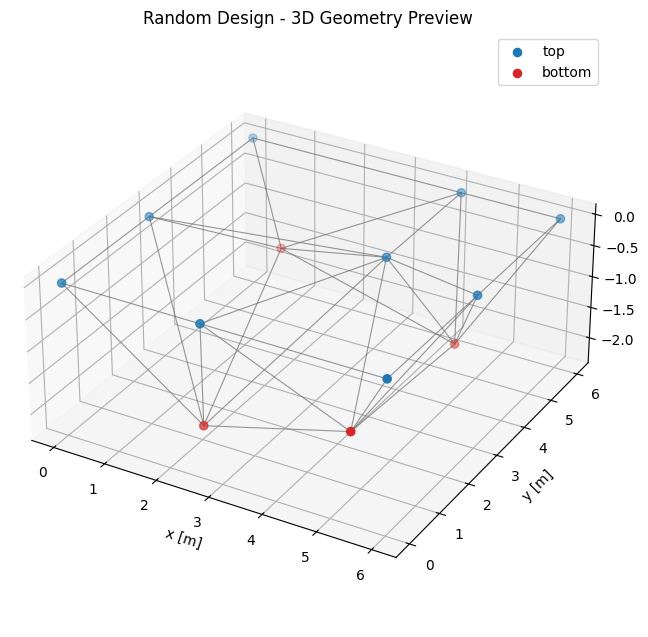

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Build a lookup so we can quickly fetch coordinates for each vertex id.
vertex_lookup = df_vertices.set_index("vertex_index")[["x", "y", "z", "layer"]].to_dict("index")

def _to_vertex_key(v):
    v_str = str(v)
    return v_str if v_str.startswith("v") else f"v{v_str}"

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw all members (edges)
for _, edge in df_edges.iterrows():
    v1 = _to_vertex_key(edge["V1"])
    v2 = _to_vertex_key(edge["V2"])

    if v1 not in vertex_lookup or v2 not in vertex_lookup:
        continue

    p1 = vertex_lookup[v1]
    p2 = vertex_lookup[v2]
    ax.plot3D(
        [p1["x"], p2["x"]],
        [p1["y"], p2["y"]],
        [p1["z"], p2["z"]],
        color="0.45",
        linewidth=0.8,
        alpha=0.75,
    )

# Draw nodes per layer for readability
df_top = df_vertices[df_vertices["layer"] == "top"]
df_bottom = df_vertices[df_vertices["layer"] == "bottom"]

ax.scatter3D(  # type: ignore
    np.asarray(df_top["x"]),
    np.asarray(df_top["y"]),
    np.asarray(df_top["z"]),
    s=35,
    c="#1f77b4",
    label="top",
)
ax.scatter3D(  # type: ignore
    np.asarray(df_bottom["x"]),
    np.asarray(df_bottom["y"]),
    np.asarray(df_bottom["z"]),
    s=35,
    c="#d62728",
    label="bottom",
)

ax.set_title("Random Design - 3D Geometry Preview")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]", labelpad=14)
ax.legend(loc="upper right")
ax.set_box_aspect((1, 1, 0.45))

# Keep extra space on the right so the z label is fully visible.
fig.subplots_adjust(left=0.06, right=0.90, bottom=0.08, top=0.93)
plt.show()

# GNN

In [5]:
import pandas as pd
import numpy as np
import json
import config
import torch
import joblib
from c21_surrogate_model import TrussEdgeGNN

# ==========================================
# 1. LOAD PRE-TRAINED SURROGATE MODEL
# ==========================================
MODEL_PREFIX = "data_4_0000"  # Change this to use different pre-trained models

print(f"Loading pre-trained surrogate model: {MODEL_PREFIX}")
checkpoint = torch.load(config.SM_EXPORT_PATH / f"truss_edge_gnn_{MODEL_PREFIX}.pt")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TrussEdgeGNN(node_in_dim=checkpoint['node_in_dim'], hidden_dim=checkpoint['hidden_dim']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Load scalers
node_scaler = joblib.load(config.SM_EXPORT_PATH / f"node_scaler_{MODEL_PREFIX}.pkl")
edge_scaler = joblib.load(config.SM_EXPORT_PATH / f"edge_scaler_{MODEL_PREFIX}.pkl")

print(f"Model and scalers loaded successfully on {device}\n")

# ==========================================
# 2. PREPARE NODE FEATURES FROM GEOMETRY
# ==========================================
data = df_vertices.copy()  # Use generated vertices as surrogate model input
df_geometry = pd.DataFrame(data)

# Ensure node features are in the correct order and format
# Expected: x, y, z coordinates (and optionally load_z, is_support if available)
node_cols = [col for col in df_geometry.columns if col.startswith('v') and col.endswith(('_x', '_y', '_z', '_load_z', '_is_support'))]

# If we do not have explicit v0_x, v0_y format, use x, y, z directly
if not node_cols:
    feature_cols = ['x', 'y', 'z']
    # Add a fourth feature to match the scaler's expected input (4 features)
    if 'load_z' in df_geometry.columns:
        feature_cols.append('load_z')
    elif 'is_support' in df_geometry.columns:
        feature_cols.append('is_support')
    else:
        # If neither exists, add a default column of zeros
        df_geometry['default_feature'] = 0.0
        feature_cols.append('default_feature')

    node_features_raw = df_geometry[feature_cols].values.astype(np.float32)
else:
    node_features_raw = df_geometry[node_cols].values.astype(np.float32)

# Scale node features
scaler_in_dim = getattr(node_scaler, "n_features_in_", node_features_raw.shape[1])

# Make raw features compatible with scaler input dimension
if node_features_raw.shape[1] < scaler_in_dim:
    pad = np.zeros((node_features_raw.shape[0], scaler_in_dim - node_features_raw.shape[1]), dtype=np.float32)
    node_features_for_scaler = np.hstack([node_features_raw, pad])
elif node_features_raw.shape[1] > scaler_in_dim:
    node_features_for_scaler = node_features_raw[:, :scaler_in_dim]
else:
    node_features_for_scaler = node_features_raw

node_features_scaled = node_scaler.transform(node_features_for_scaler)

# Make scaled features compatible with model input dimension
model_in_dim = checkpoint["node_in_dim"]
if node_features_scaled.shape[1] < model_in_dim:
    pad = np.zeros((node_features_scaled.shape[0], model_in_dim - node_features_scaled.shape[1]), dtype=np.float32)
    node_features_scaled = np.hstack([node_features_scaled, pad])
elif node_features_scaled.shape[1] > model_in_dim:
    node_features_scaled = node_features_scaled[:, :model_in_dim]

node_features_tensor = torch.from_numpy(node_features_scaled).float().to(device)

# ==========================================
# 3. PREPARE EDGE INDEX
# ==========================================
edge_index_path = config.DATA_IO_PATH / "edge_index.json"
with open(edge_index_path, "r", encoding="utf-8") as f:
    edge_index_raw = json.load(f)

# Support both [[starts], [ends]] and dictionary variants
if isinstance(edge_index_raw, dict):
    start_nodes = edge_index_raw.get("start_nodes") or edge_index_raw.get("source") or edge_index_raw.get("V1")
    end_nodes = edge_index_raw.get("end_nodes") or edge_index_raw.get("target") or edge_index_raw.get("V2")
    if start_nodes is None or end_nodes is None:
        raise ValueError("edge_index.json is missing required keys for start/end nodes.")
    edge_index = [start_nodes, end_nodes]
elif isinstance(edge_index_raw, list) and len(edge_index_raw) == 2:
    edge_index = edge_index_raw
else:
    raise ValueError("Unexpected format in edge_index.json; expected [starts, ends] or dict.")

edge_index_tensor = torch.tensor(edge_index, dtype=torch.long).to(device)

# ==========================================
# 4. RUN INFERENCE WITH REAL GNN MODEL
# ==========================================
print("Running GNN inference on geometry...")

with torch.no_grad():
    predictions_scaled = model(node_features_tensor, edge_index_tensor)

# Inverse transform predictions back to original scale (kN)
predictions_np = predictions_scaled.detach().cpu().numpy()
predictions_original = edge_scaler.inverse_transform(predictions_np)

print(f"Predictions generated for {len(predictions_original)} elements\n")

# ==========================================
# 5. FORMAT RESULTS AS DATAFRAME
# ==========================================
start_nodes = edge_index[0]
end_nodes = edge_index[1]

# Compute lengths from geometry
def get_edge_length(idx_a, idx_b):
    coord_a = df_geometry.iloc[idx_a][['x', 'y', 'z']].values.astype(float)
    coord_b = df_geometry.iloc[idx_b][['x', 'y', 'z']].values.astype(float)
    return np.linalg.norm(coord_b - coord_a)

predictions_records = []
for i in range(len(start_nodes)):
    idx_A = start_nodes[i]
    idx_B = end_nodes[i]
    length_m = get_edge_length(idx_A, idx_B)

    predictions_records.append({
        "edge_id": f"e{i}",
        "V1": f"{idx_A}",
        "V2": f"{idx_B}",
        "length_m": round(length_m, 3),
        "axial_force_kn": round(float(predictions_original[i][0]), 2),
    })

df_forces = pd.DataFrame(predictions_records)
df_forces.to_csv(config.EXPORT_PATH / "predicted_forces.csv", index=False)
print("\nExports written to 60_Research_Exports.")

print("Axial forces predicted with the surrogate model.")
print(df_forces.to_string(index=False))

c:\Users\jaspe\Documents\PyEnvs\thesis_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pre-trained surrogate model: data_4_0000
Model and scalers loaded successfully on cpu

Running GNN inference on geometry...
Predictions generated for 32 elements


Exports written to 60_Research_Exports.
Axial forces predicted with the surrogate model.
edge_id V1 V2  length_m  axial_force_kn
     e0  0  1     2.625           -1.54
     e1  0  3     2.625           -3.88
     e2  1  2     3.375           11.48
     e3  1  4     3.693           17.57
     e4  2  5     3.000           -7.78
     e5  3  4     4.193           18.06
     e6  3  6     3.375           20.62
     e7  4  5     1.912           54.07
     e8  4  7     2.625           64.06
     e9  5  8     3.000           11.06
    e10  6  7     4.125          -11.14
    e11  7  8     1.875            4.22
    e12  9 10     3.005           11.39
    e13  9 11     4.018           15.59
    e14 10 12     3.982           14.16
    e15 11 12     3.517           19.85
    e16  9  0     3.180           15.12
    e17  9  1     2

## Utilization

In [6]:
import importlib
import structural_check
from structural_check import compute_utilization_outputs

# Ensure the latest structural_check.py is used in the active kernel
importlib.reload(structural_check)
compute_utilization_outputs = structural_check.compute_utilization_outputs

# ==========================================
# STRUCTURAL CHECK (module-driven, reusable)
# ==========================================
required_vars = ["df_forces", "df_input_stock"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise ValueError("These variables are missing from previous cells: " + ", ".join(missing_vars))

outputs = compute_utilization_outputs(
    df_forces=df_forces,
    df_input_stock=df_input_stock,
    gnn_marge=1.10,
 )

# Keep notebook variables explicitly available for downstream steps
df_inventory = outputs["df_inventory"]
df_forces_local = outputs["df_forces_local"]
df_utilization_long = outputs["df_utilization_long"]
df_utilization_matrix = outputs["df_utilization_matrix"]
df_utilization_matrix_display = outputs["df_utilization_matrix_display"]
safe_options = outputs["veilige_opties"]
veilige_opties = safe_options
df_slots = outputs["df_slots"]

df_slots.to_csv(config.EXPORT_PATH / "structure_slots.csv", index=False)
print("\nExports written to 60_Research_Exports.")

print(
    f"Utilization computed for {len(df_forces_local)} members and {len(df_inventory)} stock elements."
)
print(f"Total evaluations: {len(df_utilization_long)}")
print(f"Safe combinations (utilization <= 1.0): {len(safe_options)}")

print("\nDerived slot requirements used by cost matrix:")
display(df_slots[["edge_id", "Length_Req", "Width_Req", "Depth_Req", "Utilization_Req"]].head(10))

print("\nUtilization matrix (edge_id x Member_ID): utilization or inf when infeasible")
display(df_utilization_matrix_display)

print("\nTop 10 efficient safe options:")
display(
    safe_options[[
        "edge_id",
        "Member_ID",
        "Length",
        "Width",
        "Depth",
        "axial_force_kn",
        "length_m",
        "utilization",
    ]].head(10)
)


Exports written to 60_Research_Exports.
Utilization computed for 32 members and 324 stock elements.
Total evaluations: 10368
Safe combinations (utilization <= 1.0): 9847

Derived slot requirements used by cost matrix:


,edge_id,Length_Req,Width_Req,Depth_Req,Utilization_Req
0,e0,2625.0,38.0,100.0,0.404925
1,e1,2625.0,38.0,150.0,0.680134
2,e2,3375.0,38.0,100.0,0.385724
3,e3,3693.0,38.0,100.0,0.590345
4,e4,3000.0,50.0,150.0,0.963128
5,e5,4193.0,38.0,100.0,0.606809
6,e6,3375.0,38.0,100.0,0.692824
7,e7,1912.0,75.0,100.0,0.920477
8,e8,2625.0,38.0,225.0,0.956619
9,e9,3000.0,38.0,100.0,0.371612



Utilization matrix (edge_id x Member_ID): utilization or inf when infeasible


Member_ID,NS_00000,NS_00001,NS_00002,NS_00003,NS_00004,NS_00005,NS_00006,NS_00007,NS_00008,NS_00009,...,RS_00009,RS_00010,RS_00011,RS_00012,RS_00013,RS_00014,RS_00015,RS_00016,RS_00017,RS_00018
edge_id,,,,,,,,,,,,,,,,,,,,,
e0,0.404925,0.181392,0.093001,0.056702,0.026056,0.269950,0.120928,0.062001,0.037801,0.017370,...,0.147499,0.076708,0.036462,0.027425,0.147499,0.076708,0.036462,0.027425,0.147499,0.076708
e1,inf,0.457013,0.234314,0.142859,0.065647,0.680134,0.304675,0.156210,0.095240,0.043764,...,0.371620,0.193264,0.091865,0.069096,0.371620,0.193264,0.091865,0.069096,0.371620,0.193264
e10,inf,inf,inf,0.956208,0.415963,inf,inf,inf,0.637472,0.277308,...,inf,inf,0.620496,0.460192,inf,inf,0.620496,0.460192,inf,inf
e11,0.141790,0.107761,0.085524,0.071840,0.053880,0.094527,0.071840,0.057016,0.047894,0.035920,...,0.091433,0.067230,0.042593,0.040818,0.091433,0.067230,0.042593,0.040818,0.091433,0.067230
e12,0.382700,0.290852,0.230835,0.193901,0.145426,0.255133,0.193901,0.153890,0.129267,0.096951,...,0.246783,0.181458,0.114961,0.110171,0.246783,0.181458,0.114961,0.110171,0.246783,0.181458
e13,0.523818,0.398102,0.315954,0.265401,0.199051,0.349212,0.265401,0.210636,0.176934,0.132701,...,0.337783,0.248370,0.157352,0.150796,0.337783,0.248370,0.157352,0.150796,0.337783,0.248370
e14,0.475771,0.361586,0.286973,0.241057,0.180793,0.317180,0.241057,0.191315,0.160705,0.120529,...,0.306800,0.225588,0.142919,0.136964,0.306800,0.225588,0.142919,0.136964,0.306800,0.225588
e15,0.666953,0.506884,0.402289,0.337923,0.253442,0.444635,0.337923,0.268193,0.225282,0.168961,...,0.430083,0.316238,0.200349,0.192001,0.430083,0.316238,0.200349,0.192001,0.430083,0.316238
e16,0.508026,0.386100,0.306429,0.257400,0.193050,0.338684,0.257400,0.204286,0.171600,0.128700,...,0.327600,0.240882,0.152609,0.146250,0.327600,0.240882,0.152609,0.146250,0.327600,0.240882



Top 10 efficient safe options:


,edge_id,Member_ID,Length,Width,Depth,axial_force_kn,length_m,utilization
0,e0,NS_00000,1500.0,38.0,100.0,-1.54,2.625,0.404925
34,e0,NS_00034,1800.0,38.0,100.0,-1.54,2.625,0.404925
68,e0,NS_00068,2100.0,38.0,100.0,-1.54,2.625,0.404925
102,e0,NS_00102,2400.0,38.0,100.0,-1.54,2.625,0.404925
136,e0,NS_00136,2700.0,38.0,100.0,-1.54,2.625,0.404925
170,e0,NS_00170,3000.0,38.0,100.0,-1.54,2.625,0.404925
204,e0,NS_00204,3300.0,38.0,100.0,-1.54,2.625,0.404925
238,e0,NS_00238,3600.0,38.0,100.0,-1.54,2.625,0.404925
272,e0,NS_00272,3900.0,38.0,100.0,-1.54,2.625,0.404925
5,e0,NS_00005,1500.0,38.0,150.0,-1.54,2.625,0.269950


# COST MATRIX

We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

## Validation

In [7]:
from cost_calculation import prepare_stock_cost_inputs

# Strict validation + resolved inputs used by build_cost_matrix
df_stock_prepared = prepare_stock_cost_inputs(df_input_stock) # type: ignore

print("\nStock input validated for the universal cost formula.")
print("Preview of resolved columns:")
display(
    df_stock_prepared[[
        'Member_ID',
        'State',
        'ECC',
        'ProcessingFactor',
        'PreparationFactor_Resolved',
        'mean_density',
        'Transport_Dist',
        'EmissionFactor'
    ]].head(10)
 )

Calculation modules defined successfully.

Stock input validated for the universal cost formula.
Preview of resolved columns:


,Member_ID,State,ECC,ProcessingFactor,PreparationFactor_Resolved,mean_density,Transport_Dist,EmissionFactor
0,NS_00000,0,150.0,0,0.0,420.0,1688.82,0.1743
1,NS_00001,0,150.0,0,0.0,420.0,341.61,0.1724
2,NS_00002,0,150.0,0,0.0,420.0,816.74,0.1778
3,NS_00003,0,150.0,0,0.0,420.0,1707.28,0.1771
4,NS_00004,0,150.0,0,0.0,420.0,145.43,0.1777
5,NS_00005,0,150.0,0,0.0,420.0,259.23,0.1752
6,NS_00006,0,150.0,0,0.0,420.0,1138.79,0.1727
7,NS_00007,0,150.0,0,0.0,420.0,997.58,0.1736
8,NS_00008,0,150.0,0,0.0,420.0,926.84,0.1800
9,NS_00009,0,150.0,0,0.0,420.0,430.15,0.1765


## Building of cost matrix

In [14]:
import importlib
import numpy as np
import pandas as pd
import config
import cost_calculation as cc

# Ensure latest src/cost_calculation.py is used in the active kernel
importlib.reload(cc)

build_cost_matrix = cc.build_cost_matrix
analyze_and_export_slot_logs = cc.analyze_and_export_slot_logs

# Deep-analysis settings
target_slot_for_analysis = 'e24'
all_stock_ids = df_input_stock['Member_ID'].dropna().astype(str).tolist()

# Testing behavior for full-list display
testing_mode = bool(globals().get('testing', False))
show_full_list = testing_mode

# Utilization constraint settings
utilization_threshold = 1.0
utilization_threshold_sweep = [0.90, 1.00, 1.10]
utilization_matrix_for_cost = df_utilization_matrix if 'df_utilization_matrix' in globals() else None

print(f"Deep analysis started for slot: {target_slot_for_analysis}")
print(f"Number of stock items in analysis: {len(all_stock_ids)}")
if testing_mode:
    print("Testing mode active: Full list (NS + RS) is limited to 20 rows.")
else:
    print("Testing mode off: Full list (NS + RS) will not be shown.")

if utilization_matrix_for_cost is None:
    print("No utilization matrix found; cost matrix runs without a utilization constraint.")
else:
    print(f"Utilization constraint active with threshold <= {utilization_threshold:.2f}")

    # Quick sweep to show impact on solution space
    sweep_rows = []
    for thr in utilization_threshold_sweep:
        cm_sweep, _, _ = build_cost_matrix(
            df_slots,
            df_input_stock,
            target_stock_ids=None,
            df_utilization_matrix=utilization_matrix_for_cost,
            max_utilization_threshold=thr,
        )
        finite_mask = np.isfinite(cm_sweep)
        valid_count = int(finite_mask.sum())
        total_count = int(cm_sweep.size)
        valid_ratio = (valid_count / total_count) if total_count > 0 else 0.0
        mean_cost = float(np.nanmean(np.where(finite_mask, cm_sweep, np.nan))) if valid_count > 0 else np.nan

        sweep_rows.append({
            'threshold': thr,
            'valid_combinations': valid_count,
            'total_combinations': total_count,
            'valid_ratio': round(valid_ratio, 4),
            'mean_finite_cost': round(mean_cost, 3) if np.isfinite(mean_cost) else np.nan,
        })

    df_threshold_sweep = pd.DataFrame(sweep_rows).sort_values('threshold').reset_index(drop=True)
    print("\nUtilization-threshold sweep comparison:")
    display(df_threshold_sweep)

# Build matrix and log all stock items (for all slots) using the selected threshold
cost_matrix, enriched_stock, df_logs = build_cost_matrix(
    df_slots,
    df_input_stock,
    target_stock_ids=all_stock_ids,
    df_utilization_matrix=utilization_matrix_for_cost,
    max_utilization_threshold=utilization_threshold,
)

# Present the result
# Convert to DataFrame for readable output
df_cost_matrix_display = pd.DataFrame(
    cost_matrix,
    index=[f"{row['edge_id']} ({row['Length_Req']:.0f}mm)" for _, row in df_slots.iterrows()],
    columns=enriched_stock['Member_ID'].tolist()
)

df_cost_matrix_display.to_csv(config.EXPORT_PATH / 'final_cost_matrix.csv', index=True)

# Deep analysis + export moved to cost_calculation.py
df_logs_slot, df_logs_slot_rs, analysis_export_path = analyze_and_export_slot_logs(
    df_logs=df_logs,
    target_slot_for_analysis=target_slot_for_analysis,
    all_stock_ids=all_stock_ids,
    export_dir=config.EXPORT_PATH,
    display_fn=display,
    max_full_list_rows=max_full_list_rows,
    show_full_list=show_full_list,
)

print("\nPreview Cost Matrix (first 8 members, first 5 inventory beams):")
print("(Note: 'inf' means the inventory beam is too small, fails utilization, or is otherwise excluded)\n")
print("=" * 80)
print(df_cost_matrix_display.iloc[:8, :5].round(2))

Calculation modules defined successfully.
Deep analysis started for slot: e24
Number of stock items in analysis: 324
Testing mode off: Full list (NS + RS) will not be shown.
Utilization constraint active with threshold <= 1.00
Starting generation of the integrated CO2 cost matrix (new LCA logic)...
Matrix generated! Dimensions: 32 required members x 324 inventory beams.
Physical valid combinations found: 3869
Utilization constraint active with threshold <= 0.900
Starting generation of the integrated CO2 cost matrix (new LCA logic)...
Matrix generated! Dimensions: 32 required members x 324 inventory beams.
Physical valid combinations found: 3919
Utilization constraint active with threshold <= 1.000
Starting generation of the integrated CO2 cost matrix (new LCA logic)...
Matrix generated! Dimensions: 32 required members x 324 inventory beams.
Physical valid combinations found: 3927
Utilization constraint active with threshold <= 1.100

Utilization-threshold sweep comparison:


,threshold,valid_combinations,total_combinations,valid_ratio,mean_finite_cost
0,0.9,3869,10368,0.3732,12.991
1,1.0,3919,10368,0.3780,12.882
2,1.1,3927,10368,0.3788,12.864


Starting generation of the integrated CO2 cost matrix (new LCA logic)...
Matrix generated! Dimensions: 32 required members x 324 inventory beams.
Physical valid combinations found: 3919
Utilization constraint active with threshold <= 1.000

DETAILED ANALYSIS: ALL FACTORS FOR SLOT e24

Aantal RS-items voor e24: 18


,Stock_ID,Slot_ID,Status,Feasibility_Reasons,Utilization_Value,V_req_m3,V_over_m3,V_waste_m3,V_stock_m3,Embodied_CO2,Prep_CO2,Trans_CO2,Waste_CO2,Saw_CO2,TOTAL_Score
0,RS_00001,e24,❌,"Utilization, Dimensions",1.8612,-,-,-,-,-,-,-,-,-,inf
1,RS_00002,e24,✅,Passed,0.9661,0.028682,0.0,0.007018,0.0357,0.0,0.475,0.009,0.084,0.0194,0.587
2,RS_00003,e24,❌,Length,0.4580,-,-,-,-,-,-,-,-,-,inf
3,RS_00004,e24,❌,Length,0.3433,-,-,-,-,-,-,-,-,-,inf
4,RS_00005,e24,❌,"Utilization, Dimensions",1.8612,-,-,-,-,-,-,-,-,-,inf
5,RS_00006,e24,✅,Passed,0.9661,0.028682,0.0,0.005488,0.03417,0.0,0.454,0.449,0.066,0.0194,0.989
6,RS_00007,e24,✅,Passed,0.4580,0.028682,0.016591,0.010272,0.055545,0.0,0.739,0.034,0.123,0.0194,0.916
7,RS_00008,e24,✅,Passed,0.3433,0.028682,0.018559,0.009038,0.05628,0.0,0.749,0.279,0.108,0.0194,1.155
8,RS_00009,e24,❌,"Utilization, Dimensions",1.8612,-,-,-,-,-,-,-,-,-,inf
9,RS_00010,e24,❌,Length,0.9661,-,-,-,-,-,-,-,-,-,inf



Full list (NS + RS) skipped (testing mode is off).

Detailed analysis exported to: C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\diepte_analyse_e24.csv

Preview Cost Matrix (first 8 members, first 5 inventory beams):
(Note: 'inf' means the inventory beam is too small, fails utilization, or is otherwise excluded)

             NS_00000  NS_00001  NS_00002  NS_00003  NS_00004
e0 (2625mm)       inf       inf       inf       inf       inf
e1 (2625mm)       inf       inf       inf       inf       inf
e2 (3375mm)       inf       inf       inf       inf       inf
e3 (3693mm)       inf       inf       inf       inf       inf
e4 (3000mm)       inf       inf       inf       inf       inf
e5 (4193mm)       inf       inf       inf       inf       inf
e6 (3375mm)       inf       inf       inf       inf       inf
e7 (1912mm)       inf       inf       inf       inf       inf


# MATCHING ALGORITHM / MILP

The assignment problem in this notebook is solved as a mixed-integer linear program (MILP). Let:

- $I$ be the set of required structural slots,
- $J$ be the set of inventory stock elements,
- $F \subseteq I \times J$ be the set of physically feasible slot-stock combinations,
- $R \subseteq J$ be the subset of reclaimed timber,
- $N \subseteq J$ be the subset of new timber,
- $c_{ij}$ be the cost of assigning stock element $j$ to slot $i$,
- $x_{ij} \in \{0,1\}$ be the decision variable, where $x_{ij}=1$ means that stock element $j$ is assigned to slot $i$.

$$
\min_{x} \sum_{(i,j) \in F} c_{ij} x_{ij}
$$

subject to

$$
\sum_{j:(i,j)\in F} x_{ij} = 1 \qquad \forall i \in I
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le 1 \qquad \forall j \in R
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le |I| \qquad \forall j \in N
$$

$$
x_{ij} = 0 \qquad \forall (i,j) \notin F
$$

In words: every structural member must receive exactly one feasible timber element, reclaimed timber can be used at most once, and new timber can be reused when physically feasible.

In [9]:
import pulp
import numpy as np
import pandas as pd

# ==========================================
# CELL 4: APPLY THE OPTIMIZATION ALGORITHM (MILP)
# ==========================================
print("Starting MILP optimizer for final assignment...")

# 1. CONNECT DATA FROM PREVIOUS STEPS
# Collect names from DataFrames in previous cells
stock_items = enriched_stock['Member_ID'].tolist()
construction_slots = df_slots['edge_id'].tolist()

# Dynamic categorization (checks for 'NS' and 'RS' in Member_ID)
new_items = [item for item in stock_items if 'NS' in item]
reclaimed_items = [item for item in stock_items if 'RS' in item]

print(f"Inventory: {len(reclaimed_items)} reclaimed, {len(new_items)} new elements.")
print(f"Structure requires: {len(construction_slots)} members.")

# 2. FILTER THE COST MATRIX (build sparse matrix)
# Keep only combinations that physically fit (where cost is not infinite)
valid_matches = []
costs = {}

for i, slot_id in enumerate(construction_slots):
    for j, stock_id in enumerate(stock_items):
        cost = cost_matrix[i, j]
        # If cost is not inf, it is a valid match
        if cost != np.inf:
            valid_matches.append((stock_id, slot_id))
            costs[(stock_id, slot_id)] = cost

print(f"Valid combinations reduced for solver: {len(valid_matches)}")

# 3. SET UP THE MODEL
prob = pulp.LpProblem("Reclaimed_Timber_Matching", pulp.LpMinimize)

# 4. DECISION VARIABLES
# Create variables only for feasible combinations
x = pulp.LpVariable.dicts("Match", valid_matches, 0, 1, pulp.LpBinary)

# 5. OBJECTIVE FUNCTION (minimize total CO2 penalty)
prob += pulp.lpSum([x[match] * costs[match] for match in valid_matches])

# 6. CONSTRAINTS

# Rule A: each structure member must receive exactly one timber assignment
for slot_id in construction_slots:
    # Find all stock members that fit this slot
    valid_stock_for_slot = [stock_id for (stock_id, s_id) in valid_matches if s_id == slot_id]

    if not valid_stock_for_slot:
        print(f"FATAL ERROR: Slot {slot_id} has no physically feasible stock member in inventory.")
    else:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for stock_id in valid_stock_for_slot]) == 1

# Rule B: reclaimed timber is unique (max one use)
for stock_id in reclaimed_items:
    valid_slots_for_stock = [s_id for (s_id_tuple, s_id) in valid_matches if s_id_tuple == stock_id]
    if valid_slots_for_stock:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for slot_id in valid_slots_for_stock]) <= 1

# Rule C: new timber may be reused (upper bound = number of required members)
for stock_id in new_items:
    valid_slots_for_stock = [s_id for (s_id_tuple, s_id) in valid_matches if s_id_tuple == stock_id]
    if valid_slots_for_stock:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for slot_id in valid_slots_for_stock]) <= len(construction_slots)

# ==========================================
# 7. SOLVE AND REPORT RESULTS
# ==========================================
prob.solve()

print("\n" + "="*50)
print(f"SOLUTION STATUS: {pulp.LpStatus[prob.status]}")
print("="*50)

if pulp.LpStatus[prob.status] == 'Optimal':
    total_cost = pulp.value(prob.objective)

    # Store winning combinations in a readable list
    results = []
    for j in construction_slots:
        for i in stock_items:
            match = (i, j)
            if match in x and x[match].varValue == 1:
                # Use same column names as merge step
                results.append({'edge_id': j, 'assigned_timber': i, 'CO2_Penalty': round(costs[match], 2)})

    df_results = pd.DataFrame(results)

    print(f"\nOptimal design found with total CO2 penalty {total_cost:.2f} kg.")

    # ==========================================
    # 8. MERGE WITH ORIGINAL EDGE MATRIX
    # ==========================================
    # Merge assigned_timber next to existing V1/V2 columns
    df_final_edges = pd.merge(df_slots, df_results[['edge_id', 'assigned_timber']], on='edge_id', how='left')

    print("\nFinal timber assignment:")
    print("-" * 50)
    print(df_results.to_string(index=False))
    df_results.to_csv(config.EXPORT_PATH / "final_results.csv", index=False)

    # Optional: export to CSV for coloring in Grasshopper
    # df_final_edges.to_csv('final_assignment.csv', index=False)

else:
    print("The algorithm could not find a solution. Inventory is likely insufficient for the requested structure.")

Starting MILP optimizer for final assignment...
Inventory: 18 reclaimed, 306 new elements.
Structure requires: 32 members.
Valid combinations reduced for solver: 3919
FATAL ERROR: Slot e5 has no physically feasible stock member in inventory.
FATAL ERROR: Slot e10 has no physically feasible stock member in inventory.
FATAL ERROR: Slot e13 has no physically feasible stock member in inventory.

SOLUTION STATUS: Optimal

Optimal design found with total CO2 penalty 38.06 kg.

Final timber assignment:
--------------------------------------------------
edge_id assigned_timber  CO2_Penalty
     e0        NS_00204         2.12
     e1        RS_00006         0.98
     e2        RS_00007         0.81
     e3        NS_00272         2.41
     e4        RS_00013         0.46
     e6        RS_00017         0.44
     e7        RS_00010         0.57
     e8        RS_00011         1.32
     e9        RS_00005         0.33
    e11        NS_00102         1.50
    e12        RS_00009         0.35
    

# EXPORT

This section exports the best structural parameters in a format that can be used by the Grasshopper script to reconstruct geometry.

In [10]:
# @title Export geometry + assigned stock
import pandas as pd
import config

# ==========================================
# 8. EXPORT GEOMETRY + MATCHING RESULTS
# ==========================================
# Parameters / choices
EXPORT_PREFIX = "optimum"              # e.g. "optimum", "run01", ...
EXPORT_UNASSIGNED_AS = "UNASSIGNED"    # label for edges without a match
DROP_UNASSIGNED_EDGES = False           # True = export only matched edges

print("\nExporting vertices and edges with assigned stock...")

# --- 1) Validate required data from previous cells ---
required_vars = ["df_vertices", "df_edges", "df_results"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise ValueError(
        "These variables are missing from previous cells: " + ", ".join(missing) +
        ". Run geometry, matching, and ILP cells first."
    )

# --- 2) Build edge export with assigned_timber ---
df_edges_export = df_edges.copy()
df_edges_export = pd.merge(
    df_edges_export,
    df_results[["edge_id", "assigned_timber", "CO2_Penalty"]],
    on="edge_id",
    how="left"
 )
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna(EXPORT_UNASSIGNED_AS)
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

if DROP_UNASSIGNED_EDGES:
    df_edges_export = df_edges_export[df_edges_export["assigned_timber"] != EXPORT_UNASSIGNED_AS].copy()

# --- 3) Build output file paths ---
path_vertices = config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv"
path_edges = config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges_with_stock.csv"

# --- 4) Export files ---
df_vertices.to_csv(path_vertices, index=False)
df_edges_export.to_csv(path_edges, index=False)

# --- 5) Summary ---
n_total = len(df_edges_export)
n_matched = int((df_edges_export["assigned_timber"] != EXPORT_UNASSIGNED_AS).sum())
print(f"Vertices exported: {len(df_vertices)} -> {path_vertices}")
print(f"Edges exported: {n_total} (matched: {n_matched}) -> {path_edges}")

print("\nPreview edges + assigned_timber:")
display(df_edges_export.head(10))


Exporting vertices and edges with assigned stock...
Vertices exported: 13 -> C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\optimum_vertices.csv
Edges exported: 32 (matched: 29) -> C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\optimum_edges_with_stock.csv

Preview edges + assigned_timber:


,edge_id,V1,V2,assigned_timber,CO2_Penalty
0,e0,0,1,NS_00204,2.12
1,e1,1,2,RS_00006,0.98
2,e2,3,4,RS_00007,0.81
3,e3,4,5,NS_00272,2.41
4,e4,6,7,RS_00013,0.46
5,e5,7,8,UNASSIGNED,0.00
6,e6,0,3,RS_00017,0.44
7,e7,1,4,RS_00010,0.57
8,e8,2,5,RS_00011,1.32
9,e9,3,6,RS_00005,0.33
